# DataFrames I

In [ ]:
import polars as pl

## Introducción a los DataFrames
- Un `DataFrame` es una tabla bidimensional compuesta por filas y columnas.
- Un `DataFrame` es una colección de `Series`.
- Las columnas de un `DataFrame` pueden ser de diferentes tipos de datos pero **deben tener la misma longitud**.


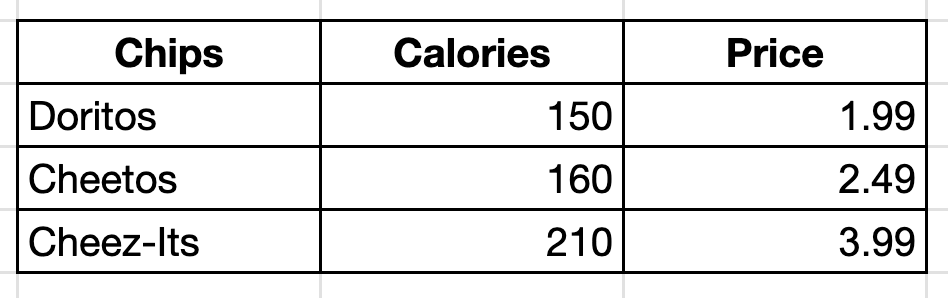

## Crear un DataFrame desde cero
- El constructor de la clase `pl.DataFrame` acepta una variedad de entradas.
- Una opción es un diccionario que mapea nombres de columnas a valores de columnas.
- Pasa una lista para los valores de cada columna. Las longitudes de las listas deben ser iguales.

In [ ]:
pl.DataFrame(
    {
        "id": [1, 2, 3, 4, 5],
        "credit_score": [3.4, 6.8, 9.2, 13.3, 18.9],
    }
)

id,credit_score
i64,f64
1,3.4
2,6.8
3,9.2
4,13.3
5,18.9


- La salida incluye la forma/dimensiones del `DataFrame` (alto x ancho).
- Polars también imprime el tipo de dato de cada columna.

### Lectura adicional
- https://docs.pola.rs/user-guide/concepts/data-types-and-structures/#dataframe
- https://docs.pola.rs/api/python/stable/reference/dataframe/index.html

## Leer un DataFrame desde CSV
- La función `pl.read_csv` importa un archivo CSV como un `DataFrame`.
- Los parámetros de la función pueden personalizar detalles como qué columnas seleccionar, cuántas filas incluir, qué valores constituyen un valor faltante, y más.
- Polars mostrará 10 filas del `DataFrame` por defecto: las primeras 5 y las últimas 5 separadas por un espacio en medio.
- Polars usa puntos suspensivos (`...`) para marcar un salto en los datos. Los datos siguen presentes; simplemente no se imprimen.

In [ ]:
employees = pl.read_csv("employees.csv")
employees

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,"""2015-03-01"""
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,"""2019-11-25"""
"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,"""2018-02-14"""
…,…,…,…,…,…
"""James Bryant""",null,"""james.bryant@polars.io""",85285,9,"""2016-05-09"""
"""Patricia Vazquez""","""Operations""","""patricia.vazquez@polars.io""",92190,6,"""2019-02-20"""
"""Katie Clay""",null,"""katie.clay@polars.io""",87151,0,"""2025-02-12"""


- El método `head` devuelve filas desde el inicio del `DataFrame`.
- El método `limit` es un alias de `head`.
- El método `tail` devuelve filas desde el final del `DataFrame`.

In [ ]:
employees.head(7)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,"""2015-03-01"""
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,"""2019-11-25"""
"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,"""2018-02-14"""
"""Melissa Page""","""Marketing""","""melissa.page@polars.io""",114120,9,"""2015-12-28"""
"""Martin Adams""",null,"""martin.adams@polars.io""",61705,0,"""2024-10-28"""


In [ ]:
employees.limit(4)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,"""2015-03-01"""
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,"""2019-11-25"""


In [ ]:
employees.tail(9)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Peter Green""","""Operations""","""peter.green@polars.io""",93617,4,"""2020-11-16"""
"""Patricia Duncan""","""Finance""","""patricia.duncan@polars.io""",188852,5,"""2020-06-14"""
"""Jennifer Murphy""",null,"""jennifer.murphy@polars.io""",79626,1,"""2024-07-13"""
"""Rachel Walker""","""HR""","""rachel.walker@polars.io""",77912,6,"""2019-04-20"""
"""James Bryant""",null,"""james.bryant@polars.io""",85285,9,"""2016-05-09"""
"""Patricia Vazquez""","""Operations""","""patricia.vazquez@polars.io""",92190,6,"""2019-02-20"""
"""Katie Clay""",null,"""katie.clay@polars.io""",87151,0,"""2025-02-12"""
"""Monique Swanson""","""Finance""","""monique.swanson@polars.io""",196704,4,"""2020-11-07"""
"""Christopher Lynch""",null,"""christopher.lynch@polars.io""",85372,3,"""2022-07-04"""


- El atributo `columns` proporciona una lista de los nombres de las columnas.
- El atributo `dtypes` proporciona una lista de los tipos de datos de las columnas.

In [ ]:
employees.columns

['name', 'department', 'email', 'salary', 'years_at_company', 'start_date']

In [ ]:
employees.dtypes

[String, String, String, Int64, Int64, String]

- El atributo `schema` devuelve un objeto `Schema` que conecta cada columna con su tipo.
- Imprimir la instancia de `Schema` muestra las relaciones entre columnas y tipos de datos.
- El formato de visualización de los tipos de datos puede diferir entre el esquema y el `DataFrame` impreso.

In [ ]:
employees.schema

Schema([('name', String),
        ('department', String),
        ('email', String),
        ('salary', Int64),
        ('years_at_company', Int64),
        ('start_date', String)])

- El `DataFrame` mostrará sus dimensiones (alto x ancho) al imprimirse.
- El alto es el número de filas, y el ancho es el número de columnas.
- Los atributos `height` y `width` proporcionan la misma información de forma.
- El atributo `shape` es una tupla con las dimensiones.

In [ ]:
employees.height

1000

In [ ]:
employees.width

6

In [ ]:
employees.shape

(1000, 6)

In [ ]:
employees

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,"""2015-03-01"""
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,"""2019-11-25"""
"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,"""2018-02-14"""
…,…,…,…,…,…
"""James Bryant""",null,"""james.bryant@polars.io""",85285,9,"""2016-05-09"""
"""Patricia Vazquez""","""Operations""","""patricia.vazquez@polars.io""",92190,6,"""2019-02-20"""
"""Katie Clay""",null,"""katie.clay@polars.io""",87151,0,"""2025-02-12"""


### Lectura adicional
- https://docs.pola.rs/user-guide/concepts/data-types-and-structures/#head
- https://docs.pola.rs/user-guide/concepts/data-types-and-structures/#tail
- https://docs.pola.rs/user-guide/concepts/data-types-and-structures/#schema
- https://docs.pola.rs/api/python/stable/reference/api/polars.read_csv.html
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.columns.html
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.dtypes.html
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.schema.html
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.height.html
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.width.html
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.shape.html

## Sin índice, no hay problema
- A diferencia de Pandas, los DataFrames de Polars no crean un índice numérico ascendente comenzando desde 0.
- El método `with_row_index` agregará una columna `index` al inicio del `DataFrame`.

In [ ]:
employees = pl.read_csv("employees.csv")
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""


In [ ]:
employees.with_row_index()

index,name,department,email,salary,years_at_company,start_date
u32,str,str,str,i64,i64,str
0,"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
1,"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""
2,"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,"""2015-03-01"""
3,"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,"""2019-11-25"""
4,"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,"""2018-02-14"""
…,…,…,…,…,…,…
995,"""James Bryant""",null,"""james.bryant@polars.io""",85285,9,"""2016-05-09"""
996,"""Patricia Vazquez""","""Operations""","""patricia.vazquez@polars.io""",92190,6,"""2019-02-20"""
997,"""Katie Clay""",null,"""katie.clay@polars.io""",87151,0,"""2025-02-12"""


- El parámetro `offset` establece el número inicial.
- Usa 1 para un índice que comience desde 1.

In [ ]:
employees.with_row_index(offset=1).head()

employees.with_row_index(offset=58).head()

index,name,department,email,salary,years_at_company,start_date
u32,str,str,str,i64,i64,str
58,"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
59,"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""
60,"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,"""2015-03-01"""
61,"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,"""2019-11-25"""
62,"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,"""2018-02-14"""


- El parámetro `name` establece el nombre de la columna de índice.

In [ ]:
employees.with_row_index(offset=58, name="id").head()

id,name,department,email,salary,years_at_company,start_date
u32,str,str,str,i64,i64,str
58,"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
59,"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""
60,"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,"""2015-03-01"""
61,"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,"""2019-11-25"""
62,"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,"""2018-02-14"""


- La función `read_csv` también soporta los parámetros `row_index_name` y `row_index_offset` para el mismo resultado.

In [ ]:
pl.read_csv("employees.csv", row_index_name="id", row_index_offset=1)

id,name,department,email,salary,years_at_company,start_date
u32,str,str,str,i64,i64,str
1,"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
2,"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""
3,"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,"""2015-03-01"""
4,"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,"""2019-11-25"""
5,"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,"""2018-02-14"""
…,…,…,…,…,…,…
996,"""James Bryant""",null,"""james.bryant@polars.io""",85285,9,"""2016-05-09"""
997,"""Patricia Vazquez""","""Operations""","""patricia.vazquez@polars.io""",92190,6,"""2019-02-20"""
998,"""Katie Clay""",null,"""katie.clay@polars.io""",87151,0,"""2025-02-12"""


### Lectura adicional
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.with_row_index.html

## Introducción a las expresiones
- Una **expresión** es una instrucción sobre cómo seleccionar o transformar datos.
- Una **expresión** es una computación futura. Es una evaluación que solo tiene significado cuando se combina con una función/método.

In [ ]:
employees = pl.read_csv("employees.csv")
employees

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,"""2015-03-01"""
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,"""2019-11-25"""
"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,"""2018-02-14"""
…,…,…,…,…,…
"""James Bryant""",null,"""james.bryant@polars.io""",85285,9,"""2016-05-09"""
"""Patricia Vazquez""","""Operations""","""patricia.vazquez@polars.io""",92190,6,"""2019-02-20"""
"""Katie Clay""",null,"""katie.clay@polars.io""",87151,0,"""2025-02-12"""


- La función `pl.col` crea una expresión que apunta a una columna.
- La expresión no tiene asociación con un `DataFrame` específico.
- Usamos la terminología "lazy" (diferida) porque la expresión es un bloque de construcción para una operación futura.
- La lógica de la expresión actual es: Localizar una columna `years_at_company`.

In [ ]:
pl.col("years_at_company")

<Expr ['col("years_at_company")'] at 0x10A715550>

In [ ]:
type(pl.col("years_at_company"))

polars.expr.expr.Expr

- Las expresiones tienen métodos. Cada método devuelve una nueva expresión con un conjunto expandido de instrucciones.
- Creemos una expresión que apunte a una columna llamada `years_at_company` y calcule el promedio de sus valores.
- La expresión es diferida. No tiene conocimiento de un `DataFrame` específico. Tampoco conoce el tipo de dato de su columna.
- La lógica de la expresión actual es: Localizar la columna `years_at_company`, calcular el promedio de sus valores.

In [ ]:
pl.col("years_at_company").mean()

<Expr ['col("years_at_company").mean()'] at 0x10A714A50>

In [ ]:
type(pl.col("years_at_company").mean())

polars.expr.expr.Expr

### Lectura adicional
- https://docs.pola.rs/user-guide/concepts/expressions-and-contexts/#expressions
- https://docs.pola.rs/api/python/stable/reference/expressions/col.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.mean.html

## Contexto

En Polars, un **contexto** es el entorno o situación en la que se evalúa una expresión.

Las expresiones en Polars son 'diferidas' (lazy), lo que significa que solo describen qué hacer (como calcular un promedio). El contexto es lo que le dice a Polars dónde y cómo aplicar esa descripción. Los tres contextos principales son:

- **Selección (select)**: Aplica expresiones sobre las columnas, resultando generalmente en una sola fila (si es agregación) o en columnas transformadas.
- **Filtrado (filter)**: Evalúa expresiones que devuelven booleanos para decidir qué filas conservar.
- **Agrupación (group_by)**: Divide los datos en grupos y luego aplica expresiones de agregación dentro de cada grupo.
Aquí tienes un ejemplo práctico de cómo una misma expresión se comporta en diferentes contextos:

## El método select - parte I
- Una expresión es una transformación diferida que no se ejecuta hasta que se usa en un _contexto_ específico.
- Un **contexto** es una situación que fuerza la computación.
- La mayor parte del trabajo con Polars consiste en combinar expresiones con métodos.

In [ ]:
employees = pl.read_csv("employees.csv")
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""


- El método `select` ejecuta una o más expresiones.
- Polars reúne los resultados de las ejecuciones de las expresiones en un nuevo `DataFrame`.
- Cada expresión del método `select` crea una nueva columna en el `DataFrame`.
- El ejemplo más simple de una expresión es seleccionar una columna. No hay transformaciones adicionales además de la _selección_ de una columna.
- Si la expresión apunta a una columna existente, Polars mantendrá el nombre de la columna en el nuevo `DataFrame`.

In [ ]:
employees.select(pl.col("years_at_company"))

years_at_company
i64
9
9
10
5
7
…
9
6
0


- El método `mean` transforma una expresión para calcular el promedio de una columna.
- En este escenario, el método `select` devuelve un `DataFrame` con una sola fila que contiene el promedio.
- La columna `years_at_company` almacena enteros pero el cálculo del promedio genera un flotante.

In [ ]:
employees.select(pl.col("years_at_company").mean())

years_at_company
f64
5.141


In [ ]:
employees.select(pl.col("years_at_company"), pl.col("name"))

# employees.select(pl.col("name"), pl.col("years_at_company"))

years_at_company,name
i64,str
9,"""Nicholas Maldonado"""
9,"""Michael Fletcher"""
10,"""Jeffrey Tanner"""
5,"""Diana Weaver"""
7,"""Sierra Ross"""
…,…
9,"""James Bryant"""
6,"""Patricia Vazquez"""
0,"""Katie Clay"""


In [ ]:
# Cuál podría ser el resultado?
# employees.select(pl.col("years_at_company").mean(), pl.col("salary"))

### Lectura adicional
- https://docs.pola.rs/user-guide/getting-started/#select
- https://docs.pola.rs/user-guide/concepts/expressions-and-contexts/#contexts
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.select.html

## Renombrar columnas
- Invoca el método `alias` en una expresión para renombrar la columna seleccionada.
- El método `alias` es otro ejemplo de un método que devuelve una nueva expresión a partir de una existente.
- La lógica de la expresión actual se convierte en: Localizar una columna `years_at_company`, calcular el promedio de sus valores, renombrar la columna a `years`.

In [ ]:
employees = pl.read_csv("employees.csv")
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""


In [ ]:
employees.select(pl.col("years_at_company").mean().alias("average"))

average
f64
5.141


- Alternativamente, pasa al método `select` un argumento con nombre (keyword argument) para establecer el nombre de la columna.
- Con cualquiera de las opciones de sintaxis, Polars devuelve un nuevo `DataFrame`.

In [ ]:
employees.select(average=pl.col("years_at_company").mean())

average
f64
5.141


- Polars generará un error si varias columnas tienen el mismo nombre.

In [ ]:
employees.select(
    pl.col("years_at_company").mean().alias("average"),
    pl.col("years_at_company").sum().alias("sum"),
)

average,sum
f64,i64
5.141,5141


In [ ]:
employees.select(
    pl.col("years_at_company").mean().alias("year_average"),
    pl.col("salary").mean().alias("salary_average"),
)

year_average,salary_average
f64,f64
5.141,109790.73


In [ ]:
employees.select(
    salary_average=pl.col("salary").mean(), salary_sum=pl.col("salary").sum()
)

salary_average,salary_sum
f64,i64
109790.73,109790730


- El método `select` es no mutativo.
- El método devuelve un nuevo `DataFrame`; _no_ modifica el `DataFrame` existente.
- Para conservar los cambios, asigna el `DataFrame` resultante a una variable.

In [ ]:
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""


### Lectura adicional
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.mean.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.sum.html

## El método select - parte II
- El método `select` soporta una variedad de opciones de sintaxis.
- Polars recomienda apuntar a cada columna con una expresión `pl.col` individual.
- La separación de columnas facilita construir diferentes expresiones para cada columna.

In [ ]:
employees = pl.read_csv("employees.csv")
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""


- La función `pl.col` crea una expresión, un bloque de construcción para futuras transformaciones.
- La función `pl.col` también soporta argumentos secuenciales así como una entrada de lista.
- La sintaxis `pl.col([])` funciona bien al aplicar operaciones consistentes a las columnas de la lista.

In [ ]:
employees.select(pl.col(["name", "salary"]))

name,salary
str,i64
"""Nicholas Maldonado""",250000
"""Michael Fletcher""",96540
"""Jeffrey Tanner""",126489
"""Diana Weaver""",84672
"""Sierra Ross""",148601
…,…
"""James Bryant""",85285
"""Patricia Vazquez""",92190
"""Katie Clay""",87151


- Polars puede realizar operaciones de agregación en cada columna seleccionada en una expresión.
- El siguiente ejemplo calcula el valor más grande dentro de las columnas `name` y `salary`.
- Para aclarar, este _no_ es el salario de Zachary Woods. Este es el salario más alto en el conjunto de datos.

In [ ]:
employees.select(pl.col(["name", "salary"]).max())

name,salary
str,i64
"""Zachary Woods""",250000


- Polars soporta múltiples argumentos de expresión en `select`.
- Esta sintaxis es la más flexible porque el código puede aplicar diferentes lógicas a diferentes columnas.

In [ ]:
employees.select(pl.col("name"), pl.col("salary")).head()

name,salary
str,i64
"""Nicholas Maldonado""",250000
"""Michael Fletcher""",96540
"""Jeffrey Tanner""",126489
"""Diana Weaver""",84672
"""Sierra Ross""",148601


- El siguiente ejemplo extrae el nombre mayor (último valor alfabético) y el salario más pequeño.
- Polars aplica diferentes operaciones a diferentes columnas.

In [ ]:
employees.select(pl.col("name").max(), pl.col("salary").min()).head()

name,salary
str,i64
"""Zachary Woods""",55011


- Polars también soporta una lista de expresiones como argumento de `select`.
- Esta sintaxis puede ser útil al construir listas dinámicas.

In [ ]:
employees.select([pl.col("name"), pl.col("salary")])

name,salary
str,i64
"""Nicholas Maldonado""",250000
"""Michael Fletcher""",96540
"""Jeffrey Tanner""",126489
"""Diana Weaver""",84672
"""Sierra Ross""",148601
…,…
"""James Bryant""",85285
"""Patricia Vazquez""",92190
"""Katie Clay""",87151


In [ ]:
columns = ["salary", "years_at_company", "name"]
employees.select([pl.col(column).max() for column in columns])

salary,years_at_company,name
i64,i64,str
250000,10,"""Zachary Woods"""


### Lectura adicional
- https://docs.pola.rs/user-guide/concepts/expressions-and-contexts/#expression-expansion
- https://docs.pola.rs/user-guide/expressions/expression-expansion/#function-col
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.select.html

## El método select III: Selección por tipo de dato
- La función `pl.col` también acepta tipos de datos de Polars.
- Todos los tipos de datos de Polars están disponibles en el espacio de nombres de nivel superior `pl`.
- El método `select` extraerá todas las columnas de ese tipo de dato.

In [ ]:
employees = pl.read_csv("employees.csv")
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""


In [ ]:
employees.select(pl.col(pl.String))

employees.select(pl.col(pl.Int64))

salary,years_at_company
i64,i64
250000,9
96540,9
126489,10
84672,5
148601,7
…,…
85285,9
92190,6
87151,0


- La función `col` soporta múltiples tipos.
- Los tipos de datos deben ser exactos. `pl.Int32` no coincidirá con una columna `pl.Int64`.

In [ ]:
employees.select(pl.col(pl.String, pl.Int64))

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,"""2015-03-01"""
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,"""2019-11-25"""
"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,"""2018-02-14"""
…,…,…,…,…,…
"""James Bryant""",null,"""james.bryant@polars.io""",85285,9,"""2016-05-09"""
"""Patricia Vazquez""","""Operations""","""patricia.vazquez@polars.io""",92190,6,"""2019-02-20"""
"""Katie Clay""",null,"""katie.clay@polars.io""",87151,0,"""2025-02-12"""


## Expresiones como bloques de construcción
- Las expresiones son pasos diferidos para aplicar a una computación futura.
- Las expresiones son bloques de construcción reutilizables que existen independientemente de un `DataFrame` específico.
- Asignemos una expresión a una variable y luego reutilicémosla en diferentes `DataFrames`.
- El conjunto de datos `todos.csv` tiene una columna `start_date`.

In [ ]:
employees = pl.read_csv("employees.csv")
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""


In [ ]:
todos = pl.read_csv("todos.csv")
todos

todos,start_date
str,str
"""Pay mortgage""","""2026-12-31"""
"""Exercise""","""2026-10-21"""
"""Study Polars""","""2026-01-01"""


In [ ]:
start_date = pl.col("start_date").alias("date")
start_date

<Expr ['col("start_date").alias("date"…'] at 0x78F627539AF0>

In [ ]:
employees.select(start_date).head()

date
str
"""2016-07-14"""
"""2016-02-13"""
"""2015-03-01"""
"""2019-11-25"""
"""2018-02-14"""


In [ ]:
todos.select(start_date)

date
str
"""2026-12-31"""
"""2026-10-21"""
"""2026-01-01"""


- A una expresión no le importa el tipo de dato de la columna.
- La función `read_csv` soporta un parámetro `try_parse_dates` para convertir columnas a fechas.
- Polars leerá la columna `start_date` como una columna `date` en lugar de una columna de cadena.
- La expresión `start_date` continúa funcionando.

In [ ]:
todos = pl.read_csv("todos.csv", try_parse_dates=True)
todos

todos,start_date
str,date
"""Pay mortgage""",2026-12-31
"""Exercise""",2026-10-21
"""Study Polars""",2026-01-01


In [ ]:
todos.select(start_date)

date
date
2026-12-31
2026-10-21
2026-01-01


## Expresiones que cuentan valores
- Las expresiones soportan métodos que crean nuevas expresiones con instrucciones expandidas.
- El método `len` cuenta todos los valores en la columna.
- El método `count` cuenta solo los valores presentes.
- El método `null_count` cuenta los valores nulos.
- Los métodos devuelven un `u32` (entero sin signo) porque el conteo debe ser 0 o positivo.

In [ ]:
employees = pl.read_csv("employees.csv")
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""


In [ ]:
# employees.select(pl.col("department"), pl.col("department").len().alias("dep_length"))

department,dep_length
str,u32
"""CEO""",1000
"""Operations""",1000
null,1000
"""HR""",1000
null,1000
…,…
null,1000
"""Operations""",1000
null,1000


In [ ]:
employees.select(
    pl.col("department").len().alias("dep_length"),
    pl.col("department").count().alias("dep_count"),
    pl.col("department").null_count().alias("dep_null_count"),
)

dep_length,dep_count,dep_null_count
u32,u32,u32
1000,845,155


In [ ]:
department = pl.col("department")

employees.select(
    department.len().alias("dep_length"),
    department.count().alias("dep_count"),
    department.null_count().alias("dep_null_count"),
)

dep_length,dep_count,dep_null_count
u32,u32,u32
1000,845,155


- El método `describe` devuelve un `DataFrame` de estadísticas para las columnas.
- Podemos invocarlo en `employees` pero no es particularmente útil para columnas no numéricas.
- Usemos `select` para seleccionar las dos columnas numéricas, luego invoquemos `describe` en el nuevo `DataFrame`.

In [ ]:
employees.describe()

# employees.select(pl.col("salary"), pl.col("years_at_company")).describe()

# employees.select(pl.col("salary", "years_at_company")).describe()

statistic,name,department,email,salary,years_at_company,start_date
str,str,str,str,f64,f64,str
"""count""","""1000""","""845""","""1000""",1000.0,1000.0,"""1000"""
"""null_count""","""0""","""155""","""0""",0.0,0.0,"""0"""
"""mean""",null,null,null,109790.73,5.141,null
"""std""",null,null,null,40031.948121,3.241238,null
"""min""","""Aaron Castro""","""CEO""","""aaron.castro@polars.io""",55011.0,0.0,"""2014-07-24"""
"""25%""",null,null,null,77675.0,2.0,null
"""50%""",null,null,null,96767.0,5.0,null
"""75%""",null,null,null,135842.0,8.0,null
"""max""","""Zachary Woods""","""Sales""","""zachary.woods@polars.io""",250000.0,10.0,"""2025-07-16"""


- Otra forma de resolver este problema es seleccionar las columnas por su tipo de dato compartido `pl.Int64`.

In [ ]:
employees.select(pl.col(pl.Int64)).describe()

statistic,salary,years_at_company
str,f64,f64
"""count""",1000.0,1000.0
"""null_count""",0.0,0.0
"""mean""",109790.73,5.141
"""std""",40031.948121,3.241238
"""min""",55011.0,0.0
"""25%""",77675.0,2.0
"""50%""",96767.0,5.0
"""75%""",135842.0,8.0
"""max""",250000.0,10.0


### Lectura adicional
- https://docs.pola.rs/user-guide/concepts/data-types-and-structures/#describe
- https://docs.pola.rs/user-guide/transformations/time-series/parsing/#parsing-dates-from-a-file
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.len.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.count.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.null_count.html

## Extraer una o más filas
- A diferencia de Pandas, Polars no mantiene un índice (un identificador único para cada fila).
- Polars almacena sus datos en formato columnar. Está optimizado para operaciones de columnas.

In [ ]:
employees = pl.read_csv("employees.csv")
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""


- Aún podemos extraer los valores de una fila por su posición de índice.
- Polars agregará los valores de una fila a través de todas sus columnas.
- El método `row` devuelve una tupla con los valores de una sola fila.
- Una tupla es una colección inmutable y secuenciada de valores.

In [ ]:
employees.row(0)
employees.row(1)
employees.row(100)

('Nathan Blanchard',
 'Marketing',
 'nathan.blanchard@polars.io',
 96290,
 7,
 '2018-01-22')

- El método `slice` extrae múltiples filas por sus posiciones de índice.
- El primer argumento es el índice de la fila inicial.
- El segundo argumento es el número de filas a extraer.
- El siguiente ejemplo comienza en el índice 1 (fila 2) y extrae 4 filas.
- Las filas tienen posiciones de índice 1, 2, 3 y 4 en `employees`.

In [ ]:
employees.slice(1, 4)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,"""2015-03-01"""
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,"""2019-11-25"""
"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,"""2018-02-14"""


- El primer argumento soporta valores negativos.
- Un valor negativo comienza relativo al final del `DataFrame`.
- Ejemplo: `(-8, 3)` comienza 8 filas desde el final del `DataFrame` y extrae 3 filas.

In [ ]:
employees.slice(-8, 3)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Patricia Duncan""","""Finance""","""patricia.duncan@polars.io""",188852,5,"""2020-06-14"""
"""Jennifer Murphy""",null,"""jennifer.murphy@polars.io""",79626,1,"""2024-07-13"""
"""Rachel Walker""","""HR""","""rachel.walker@polars.io""",77912,6,"""2019-04-20"""


### Lectura adicional
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.row.html
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.slice.html

## Sintaxis de slicing de listas
- Polars soporta la sintaxis de slicing de listas de Python.
- Este enfoque generalmente es desaconsejado por el equipo de Polars. Prefiere `slice` y enfoques basados en métodos.

In [ ]:
employees = pl.read_csv("employees.csv")
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""


- Un solo valor selecciona una fila por posición de índice.

In [ ]:
employees[5]

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Melissa Page""","""Marketing""","""melissa.page@polars.io""",114120,9,"""2015-12-28"""


- La sintaxis de rebanado de listas selecciona múltiples filas por posición de índice.
- La posición final es exclusiva; la fila en ese índice será excluida.
- Resta el primer índice del segundo índice para calcular el número de filas.

In [ ]:
employees[5:8]

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Melissa Page""","""Marketing""","""melissa.page@polars.io""",114120,9,"""2015-12-28"""
"""Martin Adams""",null,"""martin.adams@polars.io""",61705,0,"""2024-10-28"""
"""Jessica Hill""","""Marketing""","""jessica.hill@polars.io""",135265,5,"""2019-10-04"""


- Omite el valor antes de los dos puntos para extraer desde el inicio del `DataFrame`.

In [ ]:
employees[0:4]

employees[:4]

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,"""2015-03-01"""
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,"""2019-11-25"""


- Polars soporta valores negativos en una o ambas posiciones.

In [ ]:
employees[-10:-7]

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Tina Miller""","""Finance""","""tina.miller@polars.io""",196962,9,"""2016-06-04"""
"""Peter Green""","""Operations""","""peter.green@polars.io""",93617,4,"""2020-11-16"""
"""Patricia Duncan""","""Finance""","""patricia.duncan@polars.io""",188852,5,"""2020-06-14"""


- Omite el valor después de los dos puntos para extraer hasta el final del `DataFrame`.

In [ ]:
employees[-2:]

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Monique Swanson""","""Finance""","""monique.swanson@polars.io""",196704,4,"""2020-11-07"""
"""Christopher Lynch""",null,"""christopher.lynch@polars.io""",85372,3,"""2022-07-04"""


## Expresiones que apuntan a valores de filas

In [ ]:
employees = pl.read_csv("employees.csv")
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""


- Invoca el método `get` en una expresión para apuntar a un valor en una columna específica.

In [ ]:
employees.select(pl.col("name").get(499))

name
str
"""Rachel Morris"""


In [ ]:
employees.select(pl.col("name").get(499), pl.col("email").get(499))

name,email
str,str
"""Rachel Morris""","""rachel.morris@polars.io"""


- Este es un ejemplo donde múltiples expresiones crean código más extenso.
- Podemos pasar múltiples valores a `pl.col` para que la expresión apunte a múltiples columnas.

In [ ]:
employees.select(pl.col("name", "email").get(499))

name,email
str,str
"""Rachel Morris""","""rachel.morris@polars.io"""


- Pasar a `pl.col` una lista completa de columnas rápidamente se vuelve extenso.
- La función auxiliar `pl.all` devuelve una expresión que apunta a todas las columnas.

In [ ]:
employees.select(pl.all().get(499))

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Rachel Morris""","""Finance""","""rachel.morris@polars.io""",168722,6,"""2018-08-28"""


- Pasar un asterisco (`*`) a `pl.col` también apunta a todas las columnas.

In [ ]:
employees.select(pl.col("*").get(499))

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Rachel Morris""","""Finance""","""rachel.morris@polars.io""",168722,6,"""2018-08-28"""


### Lectura adicional
- https://docs.pola.rs/user-guide/expressions/expression-expansion/#selecting-all-columns
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.get.html

## Extraer un solo valor de un DataFrame

In [ ]:
employees = pl.read_csv("employees.csv")
employees.head(3)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,"""2015-03-01"""


- El método `item` extrae un solo valor de celda por su posición de índice de fila y columna.
- El primer argumento es el índice de la fila, el segundo argumento es el índice de la columna.
- Tanto el índice de fila como el de columna comienzan a contar desde 0.

In [ ]:
employees.item(0, 0)
employees.item(row=0, column=0)

'Nicholas Maldonado'

In [ ]:
employees.item(0, 1)

'CEO'

In [ ]:
employees.item(343, 3)

148647

- Ten cuidado. Los valores nulos/faltantes no tendrán una representación impresa.
- Envuelve el valor en la función `print` de Python para ver el `None` visual.
- El tipo de dato `None` de Python representa un valor ausente/faltante.

In [ ]:
employees.item(2, 1)

In [ ]:
print(employees.item(2, 1))

None


### Lectura adicional
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.item.html

## Los métodos `gather` y `gather_every`
- El método `gather` extrae múltiples filas por posición de índice.
- Pasa al método una lista con las posiciones de índice.

In [ ]:
employees = pl.read_csv("employees.csv")
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""


- El siguiente ejemplo usa `pl.all` para apuntar a todas las columnas, luego extrae las filas en las posiciones de índice 0, 100 y 200.

In [ ]:
employees.select(pl.all().gather([0, 100, 200]))

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Nathan Blanchard""","""Marketing""","""nathan.blanchard@polars.io""",96290,7,"""2018-01-22"""
"""George Thomas""",null,"""george.thomas@polars.io""",55386,10,"""2014-09-06"""


- El método `gather_every` extrae filas usando un intervalo/gap.
- El siguiente ejemplo selecciona cada segunda fila (posiciones de índice 0, 2, 4, etc).

In [ ]:
employees.select(pl.all().gather_every(2))

# employees.select(pl.all().gather_every(3))

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,"""2015-03-01"""
"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,"""2018-02-14"""
"""Martin Adams""",null,"""martin.adams@polars.io""",61705,0,"""2024-10-28"""
"""Matthew Garcia""","""Marketing""","""matthew.garcia@polars.io""",118913,9,"""2016-02-25"""
…,…,…,…,…,…
"""Tina Miller""","""Finance""","""tina.miller@polars.io""",196962,9,"""2016-06-04"""
"""Patricia Duncan""","""Finance""","""patricia.duncan@polars.io""",188852,5,"""2020-06-14"""
"""Rachel Walker""","""HR""","""rachel.walker@polars.io""",77912,6,"""2019-04-20"""


- El método `gather_every` también está disponible en el `DataFrame`.

In [ ]:
employees.gather_every(n=2, offset=1)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,"""2019-11-25"""
"""Melissa Page""","""Marketing""","""melissa.page@polars.io""",114120,9,"""2015-12-28"""
"""Jessica Hill""","""Marketing""","""jessica.hill@polars.io""",135265,5,"""2019-10-04"""
"""Gregory Ward""",null,"""gregory.ward@polars.io""",134169,7,"""2018-06-16"""
…,…,…,…,…,…
"""Peter Green""","""Operations""","""peter.green@polars.io""",93617,4,"""2020-11-16"""
"""Jennifer Murphy""",null,"""jennifer.murphy@polars.io""",79626,1,"""2024-07-13"""
"""James Bryant""",null,"""james.bryant@polars.io""",85285,9,"""2016-05-09"""


### Lectura adicional
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.gather.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.gather_every.html
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.gather_every.html

## Extraer un conjunto aleatorio de valores

In [ ]:
employees = pl.read_csv("employees.csv")
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""


- El método `sample` extrae un número de filas aleatorias del `DataFrame`.
- El nuevo `DataFrame` puede contener las filas en un orden diferente al que aparecen en el `DataFrame`.

In [ ]:
employees.sample(n=3)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Mindy Thomas""",null,"""mindy.thomas@polars.io""",78717,8,"""2016-11-01"""
"""George Hunter""","""Marketing""","""george.hunter@polars.io""",110696,4,"""2020-09-14"""
"""Sarah Barnett""",null,"""sarah.barnett@polars.io""",67873,4,"""2020-08-31"""


- El parámetro `fraction` extrae una porción/porcentaje de las filas originales.
- El siguiente ejemplo extrae el 3.5% de las filas originales.

In [ ]:
employees.sample(fraction=0.035)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Paul Kennedy""","""Finance""","""paul.kennedy@polars.io""",171435,1,"""2023-10-12"""
"""Stacy Ward""","""Operations""","""stacy.ward@polars.io""",100734,2,"""2023-06-06"""
"""Ernest Jordan""","""HR""","""ernest.jordan@polars.io""",63978,5,"""2019-10-06"""
"""Shaun Pruitt""","""Operations""","""shaun.pruitt@polars.io""",102519,3,"""2022-02-07"""
"""Craig Ramirez""","""Sales""","""craig.ramirez@polars.io""",71429,1,"""2024-04-06"""
…,…,…,…,…,…
"""Alicia Jones""","""Sales""","""alicia.jones@polars.io""",80066,0,"""2025-02-10"""
"""Hannah Elliott""","""Operations""","""hannah.elliott@polars.io""",104866,9,"""2016-05-28"""
"""Brooke Gillespie""","""Marketing""","""brooke.gillespie@polars.io""",124321,10,"""2015-01-03"""


### Lectura adicional
- https://docs.pola.rs/user-guide/concepts/data-types-and-structures/#sample
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.sample.html

## Conversión de tipos de columnas
- El método `cast` convierte los valores de una columna a otro tipo de dato.
- Pasa al método `cast` un tipo de dato integrado de Polars. Por ejemplo, `pl.Float64` intentará convertir a flotantes de 64 bits.
- Polars es estricto por defecto; generará un error si un solo valor no puede ser convertido.

In [ ]:
employees = pl.read_csv("employees.csv")
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,str
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,"""2016-07-14"""
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,"""2016-02-13"""


- Al aplicar una expresión, Polars mantendrá el nombre de columna original por defecto.
- Polars generará un error si varias columnas en un nuevo `DataFrame` tienen el mismo nombre.
- El método `select` por lo tanto requiere que cada expresión produzca una columna con un nombre único.

In [ ]:
employees.select(
    pl.col("salary"), pl.col("salary").cast(pl.Float64).alias("salary_as_float")
)

salary,salary_as_float
i64,f64
250000,250000.0
96540,96540.0
126489,126489.0
84672,84672.0
148601,148601.0
…,…
85285,85285.0
92190,92190.0
87151,87151.0


- El tipo `Int8` soporta el rango de valores de -128 a 127. ¡Nadie trabajará 127 años en la empresa!
- El tipo `UInt8` soporta el rango de valores de 0 a 255.


In [ ]:
employees.select(pl.col("years_at_company").cast(pl.Int8))
employees.select(pl.col("years_at_company").cast(pl.UInt8))

years_at_company
u8
9
9
10
5
7
…
9
6
0


- Podemos convertir múltiples columnas a nuevos tipos en una sola llamada a `select`.

In [ ]:
employees.select(
    pl.col("years_at_company").cast(pl.UInt8), pl.col("start_date").cast(pl.Date)
)

years_at_company,start_date
u8,date
9,2016-07-14
9,2016-02-13
10,2015-03-01
5,2019-11-25
7,2018-02-14
…,…
9,2016-05-09
6,2019-02-20
0,2025-02-12


- Recuerda que `pl.col` puede crear una expresión que apunte a múltiples columnas.
- Pasa a la función `pl.col` el tipo de dato como objetivo.

In [ ]:
employees.select(pl.col(pl.Int64).cast(pl.Float64))

salary,years_at_company
f64,f64
250000.0,9.0
96540.0,9.0
126489.0,10.0
84672.0,5.0
148601.0,7.0
…,…
85285.0,9.0
92190.0,6.0
87151.0,0.0


### Lectura adicional
- https://docs.pola.rs/user-guide/expressions/casting/#basic-example
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.cast.html

## Personalizar el esquema del DataFrame
- El parámetro `schema_overrides` sobrescribe el tipo de dato inferido por Polars para columnas específicas.
- El parámetro acepta un diccionario que mapea nombres de columnas a los tipos de datos deseados.

In [ ]:
employees = pl.read_csv(
    "employees.csv",
    schema_overrides={"years_at_company": pl.Int8, "start_date": pl.Date},
)
employees.head(1)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i8,date
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14


- El parámetro `schema` también está disponible pero requiere la provisión explícita de cada columna.
- Polars generará un error `ComputeError` si falta una columna.

In [ ]:
employees = pl.read_csv(
    "employees.csv",
    schema={
        "name": pl.String,
        "department": pl.String,
        "email": pl.String,
        "salary": pl.Int32,
        "years_at_company": pl.Int8,
        "start_date": pl.Date,
    },
)
employees.head(1)

name,department,email,salary,years_at_company,start_date
str,str,str,i32,i8,date
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14


- El atributo `schema` imprime el esquema actual del `DataFrame`.

In [ ]:
employees.schema

Schema([('name', String),
        ('department', String),
        ('email', String),
        ('salary', Int32),
        ('years_at_company', Int8),
        ('start_date', Date)])

- Una alternativa a especificar tipos `pl.Date` o `pl.DateTime` es usar el parámetro `try_parse_dates`.
- El parámetro `try_parse_dates` intenta parsear cadenas como fechas/datetimes (si Polars puede deducir el formato).
- El parámetro acepta un booleano.

In [ ]:
pl.read_csv("employees.csv", try_parse_dates=True)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,date
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,2016-02-13
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,2015-03-01
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,2019-11-25
"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,2018-02-14
…,…,…,…,…,…
"""James Bryant""",null,"""james.bryant@polars.io""",85285,9,2016-05-09
"""Patricia Vazquez""","""Operations""","""patricia.vazquez@polars.io""",92190,6,2019-02-20
"""Katie Clay""",null,"""katie.clay@polars.io""",87151,0,2025-02-12


### Lectura adicional
- https://docs.pola.rs/api/python/stable/reference/datatypes.html

## Renombrar columnas con `rename`
- El método `select` puede renombrar columnas en el nuevo `DataFrame` pero debemos especificar todas las columnas que queremos incluir.

In [ ]:
employees = pl.read_csv("employees.csv", try_parse_dates=True)
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,date
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,2016-02-13


In [ ]:
employees.select(pl.col("name").alias("first_name"))

first_name
str
"""Nicholas Maldonado"""
"""Michael Fletcher"""
"""Jeffrey Tanner"""
"""Diana Weaver"""
"""Sierra Ross"""
…
"""James Bryant"""
"""Patricia Vazquez"""
"""Katie Clay"""


- El método `rename` acepta un diccionario donde cada clave es un nombre de columna existente y cada valor es su nuevo nombre.
- Renombra las columnas especificadas mientras mantiene las existentes.

In [ ]:
employees.rename({"years_at_company": "years", "salary": "pay"})

name,department,email,pay,years,start_date
str,str,str,i64,i64,date
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,2016-02-13
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,2015-03-01
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,2019-11-25
"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,2018-02-14
…,…,…,…,…,…
"""James Bryant""",null,"""james.bryant@polars.io""",85285,9,2016-05-09
"""Patricia Vazquez""","""Operations""","""patricia.vazquez@polars.io""",92190,6,2019-02-20
"""Katie Clay""",null,"""katie.clay@polars.io""",87151,0,2025-02-12


### Lectura adicional
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.rename.html

## El atributo name
- Polars anida métodos de expresión adicionales bajo atributos que agrupan operaciones similares.
- El atributo `name` contiene métodos para ajustar nombres de columnas.
- El método `name.to_uppercase` convierte todos los nombres de columnas a mayúsculas.
- El método `name.to_lowercase` convierte todos los nombres de columnas a minúsculas.

In [ ]:
employees = pl.read_csv("employees.csv", try_parse_dates=True)
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,date
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,2016-02-13


In [ ]:
employees.select(pl.all().name.to_uppercase())

EMPLOYEE_NAME,DEPT,EMAIL,SALARY,YEARS_AT_COMPANY,START_DAY
str,str,str,i64,i64,date
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,2016-02-13
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,2015-03-01
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,2019-11-25
"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,2018-02-14
…,…,…,…,…,…
"""James Bryant""",null,"""james.bryant@polars.io""",85285,9,2016-05-09
"""Patricia Vazquez""","""Operations""","""patricia.vazquez@polars.io""",92190,6,2019-02-20
"""Katie Clay""",null,"""katie.clay@polars.io""",87151,0,2025-02-12


In [ ]:
employees.select(pl.all().name.to_lowercase())

employee_name,dept,email,salary,years_at_company,start_day
str,str,str,i64,i64,date
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,2016-02-13
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,2015-03-01
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,2019-11-25
"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,2018-02-14
…,…,…,…,…,…
"""James Bryant""",null,"""james.bryant@polars.io""",85285,9,2016-05-09
"""Patricia Vazquez""","""Operations""","""patricia.vazquez@polars.io""",92190,6,2019-02-20
"""Katie Clay""",null,"""katie.clay@polars.io""",87151,0,2025-02-12


- El método `name.prefix` concatena un texto consistente antes de cada nombre de columna.
- El método `name.suffix` concatena un texto consistente después de cada nombre de columna.

In [ ]:
employees.select(pl.all().name.prefix("emp_"))

emp_employee_name,emp_dept,emp_email,emp_salary,emp_years_at_company,emp_start_day
str,str,str,i64,i64,date
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,2016-02-13
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,2015-03-01
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,2019-11-25
"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,2018-02-14
…,…,…,…,…,…
"""James Bryant""",null,"""james.bryant@polars.io""",85285,9,2016-05-09
"""Patricia Vazquez""","""Operations""","""patricia.vazquez@polars.io""",92190,6,2019-02-20
"""Katie Clay""",null,"""katie.clay@polars.io""",87151,0,2025-02-12


In [ ]:
employees.select(pl.all().name.suffix("_value"))

employee_name_value,dept_value,email_value,salary_value,years_at_company_value,start_day_value
str,str,str,i64,i64,date
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,2016-02-13
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,2015-03-01
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,2019-11-25
"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,2018-02-14
…,…,…,…,…,…
"""James Bryant""",null,"""james.bryant@polars.io""",85285,9,2016-05-09
"""Patricia Vazquez""","""Operations""","""patricia.vazquez@polars.io""",92190,6,2019-02-20
"""Katie Clay""",null,"""katie.clay@polars.io""",87151,0,2025-02-12


### Lectura adicional
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.name.to_uppercase.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.name.to_lowercase.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.name.prefix.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.name.suffix.html

## Eliminar columnas
- El método `drop` elimina una o más columnas de un `DataFrame`.
- Usar `select` para seleccionar solo las columnas que deseas conservar es otra estrategia válida.

In [ ]:
employees = pl.read_csv("employees.csv", try_parse_dates=True)
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,date
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,2016-02-13


In [ ]:
employees.drop(pl.col("start_date"))
# employees.drop("start_date")

# employees.drop(pl.col("start_date"), pl.col("department"))
# employees.drop(pl.col("start_date", "department"))

# employees.drop("start_date", "department")
# employees.drop(pl.col(["start_date", "department"]))

name,department,email,salary,years_at_company
str,str,str,i64,i64
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5
"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7
…,…,…,…,…
"""James Bryant""",null,"""james.bryant@polars.io""",85285,9
"""Patricia Vazquez""","""Operations""","""patricia.vazquez@polars.io""",92190,6
"""Katie Clay""",null,"""katie.clay@polars.io""",87151,0


- Una columna inexistente generará un error.

In [ ]:
employees.drop("start_date", "department")

employees.drop(pl.col("start_date"), pl.col("department"))

name,email,salary,years_at_company
str,str,i64,i64
"""Nicholas Maldonado""","""nicholas.maldonado@polars.io""",250000,9
"""Michael Fletcher""","""michael.fletcher@polars.io""",96540,9
"""Jeffrey Tanner""","""jeffrey.tanner@polars.io""",126489,10
"""Diana Weaver""","""diana.weaver@polars.io""",84672,5
"""Sierra Ross""","""sierra.ross@polars.io""",148601,7
…,…,…,…
"""James Bryant""","""james.bryant@polars.io""",85285,9
"""Patricia Vazquez""","""patricia.vazquez@polars.io""",92190,6
"""Katie Clay""","""katie.clay@polars.io""",87151,0


In [ ]:
# Recordatorio: en polars se retorna una copia
# employees

### Lectura adicional
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.drop.html

## Reemplazar valores con `replace`
- El método `replace` intercambia un valor por otro.
- El método acepta una lista de valores a reemplazar con una lista de otros valores.
- Polars empareja los valores basándose en posiciones de índice compartidas.
- El método también acepta un diccionario de correspondencias.

In [ ]:
employees = pl.read_csv("employees.csv", try_parse_dates=True)
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,date
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,2016-02-13


- El código a continuación reemplaza `HR` con `Human Resources` y `Engineering` con `Tech`.

In [ ]:
employees.select(
    pl.col("department")
)

department
str
"""CEO"""
"""Operations"""
null
"""HR"""
null
…
null
"""Operations"""
null


In [ ]:
employees.select(
    pl.col("department").replace(
        old=["HR", "Engineering"], new=["Human Resources", "Tech"]
    )
)

department
str
"""CEO"""
"""Operations"""
null
"""Human Resources"""
null
…
null
"""Operations"""
null


In [ ]:
employees.select(
    pl.col("department").replace({"HR": "Human Resources", "Engineering": "Nerds"})
)

department
str
"""CEO"""
"""Operations"""
null
"""Human Resources"""
null
…
null
"""Operations"""
null


### Lectura adicional
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.replace.html

## Operaciones matemáticas - parte I
- Polars soporta operaciones matemáticas comunes en `DataFrames` y `Series`.
- La mayoría de los símbolos matemáticos tienen métodos equivalentes.

In [ ]:
employees = pl.read_csv("employees.csv", try_parse_dates=True)
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,date
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,2016-02-13


- Las operaciones sobre valores `null` (faltantes) producirán valores `null`.
- Si usas el método `alias`, envuelve la expresión completa entre paréntesis.

In [ ]:
df1 = employees.select(
    pl.col("salary"),
    addition=pl.col("salary") + 10000,
    subtraction=pl.col("salary") - 12345,
    multiplication=pl.col("salary") * 2,
    division=pl.col("salary") / 10,
    floor_division=pl.col("salary") // 10,
    years=pl.col("years_at_company"),
    exponentiation=pl.col("years_at_company") ** 3,
    remainder=pl.col("years_at_company") % 3,
)
df1.head(3)

salary,addition,subtraction,multiplication,division,floor_division,years,exponentiation,remainder
i64,i64,i64,i64,f64,i64,i64,i64,i64
250000,260000,237655,500000,25000.0,25000,9,729,0
96540,106540,84195,193080,9654.0,9654,9,729,0
126489,136489,114144,252978,12648.9,12648,10,1000,1


- Polars proporciona métodos equivalentes para los operadores matemáticos.

In [ ]:
df2 = employees.select(
    pl.col("salary"),
    addition=pl.col("salary").add(10000),
    subtraction=pl.col("salary").sub(12345),
    multiplication=pl.col("salary").mul(2),
    division=pl.col("salary").truediv(10),
    floor_division=pl.col("salary").floordiv(10),
    years=pl.col("years_at_company"),
    exponentiation=pl.col("years_at_company").pow(3),
    remainder=pl.col("years_at_company").mod(3),
)
df2.head(3)

salary,addition,subtraction,multiplication,division,floor_division,years,exponentiation,remainder
i64,i64,i64,i64,f64,i64,i64,i64,i64
250000,260000,237655,500000,25000.0,25000,9,729,0
96540,106540,84195,193080,9654.0,9654,9,729,0
126489,136489,114144,252978,12648.9,12648,10,1000,1


- El método `equals` compara la igualdad de dos `DataFrames`.
- Todos los valores de fila y nombres de columna deben ser iguales.

In [ ]:
df1.equals(df2)

True

### Lectura adicional
- https://docs.pola.rs/user-guide/expressions/basic-operations/#basic-arithmetic
- https://docs.pola.rs/user-guide/expressions/basic-operations/#comparisons
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.add.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.sub.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.mul.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.truediv.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.floordiv.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.pow.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.mod.html

## Operaciones matemáticas - parte II
- Una expresión puede referenciar múltiples columnas.
- La expresión a continuación multiplica los valores de la columna `years_at_company` por los valores de la columna `salary`.

In [ ]:
employees = pl.read_csv("employees.csv", try_parse_dates=True)
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,date
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,2016-02-13


In [ ]:
employees.select(
    pl.col("salary"),
    pl.col("years_at_company"),
    (pl.col("salary") * pl.col("years_at_company")).alias("total_spend"),
)

salary,years_at_company,total_spend
i64,i64,i64
250000,9,2250000
96540,9,868860
126489,10,1264890
84672,5,423360
148601,7,1040207
…,…,…
85285,9,767565
92190,6,553140
87151,0,0


- Polars manejará elegantemente la conversión de tipos en operaciones aritméticas si es necesario.
- Por ejemplo, multiplicar un entero por un flotante producirá un flotante.

In [ ]:
employees.select(pl.col("salary"), (pl.col("salary") * 1.05).alias("salary next year"))

salary,salary next year
i64,f64
250000,262500.0
96540,101367.0
126489,132813.45
84672,88905.6
148601,156031.05
…,…
85285,89549.25
92190,96799.5
87151,91508.55


## Operaciones matemáticas acumulativas
- Polars incluye métodos acumulativos que calculan el cambio de una fila a la siguiente.

In [ ]:
employees = pl.read_csv("employees.csv", try_parse_dates=True)
employees.head(4)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,date
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,2016-02-13
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,2015-03-01
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,2019-11-25


- El método `cum_sum` devuelve la suma acumulativa hasta e incluyendo esa fila.
- El método `cum_count` cuenta el número de valores presentes (excluye `null`) por cada fila.
- El método `cum_max` devuelve el valor más grande encontrado hasta el momento.
- El método `cum_min` devuelve el valor más pequeño encontrado hasta el momento.
- El método `cum_prod` devuelve el producto acumulativo hasta e incluyendo esa fila.
- El método `pct_change` devuelve el cambio porcentual entre la fila actual y la anterior.

In [ ]:
employees.select(
    pl.col("years_at_company"),
    cum_sum=pl.col("years_at_company").cum_sum(),
    cum_count=pl.col("years_at_company").cum_count(),
    cum_max=pl.col("years_at_company").cum_max(),
    cum_min=pl.col("years_at_company").cum_min(),
    cum_prod=pl.col("years_at_company").cum_prod(),
    pct_change=pl.col("years_at_company").pct_change() * 100,
)

years_at_company,cum_sum,cum_count,cum_max,cum_min,cum_prod,pct_change
i64,i64,u32,i64,i64,i64,f64
9,9,1,9,9,9,null
9,18,2,9,9,81,0.0
10,28,3,10,9,810,11.111111
5,33,4,10,5,4050,-50.0
7,40,5,10,5,28350,40.0
…,…,…,…,…,…,…
9,5128,996,10,0,0,50.0
6,5134,997,10,0,0,-33.333333
0,5134,998,10,0,0,-100.0


### Lectura adicional
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.cum_sum.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.cum_count.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.cum_max.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.cum_min.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.cum_prod.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.Expr.pct_change.html

## El método `with_columns`
- El método `with_columns` crea un nuevo `DataFrame` con todas las columnas existentes y las nuevas columnas de las expresiones.
- El método `with_columns` agrega las columnas al extremo derecho del `DataFrame` existente.

In [ ]:
employees = pl.read_csv("employees.csv", try_parse_dates=True)
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,date
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,2016-02-13


In [ ]:
employees.select(next_year_salary=pl.col("salary") * 1.05)

next_year_salary
f64
262500.0
101367.0
132813.45
88905.6
156031.05
…
89549.25
96799.5
91508.55


In [ ]:
employees.with_columns(next_year_salary=pl.col("salary") * 1.05)

# employees.with_columns((pl.col("salary") * 1.05).alias("next_year_salary"))

name,department,email,salary,years_at_company,start_date,next_year_salary
str,str,str,i64,i64,date,f64
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14,262500.0
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,2016-02-13,101367.0
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,2015-03-01,132813.45
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,2019-11-25,88905.6
"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,2018-02-14,156031.05
…,…,…,…,…,…,…
"""James Bryant""",null,"""james.bryant@polars.io""",85285,9,2016-05-09,89549.25
"""Patricia Vazquez""","""Operations""","""patricia.vazquez@polars.io""",92190,6,2019-02-20,96799.5
"""Katie Clay""",null,"""katie.clay@polars.io""",87151,0,2025-02-12,91508.55


- El método `with_columns` **sobrescribe** la columna original si una nueva columna tiene el mismo nombre.

In [ ]:
# employees.with_columns(pl.col("salary") * 1.05)  # sobreescribe

# employees.select(pl.col("salary"), pl.col("salary") * 1.05)  # error

- Polars ejecuta expresiones independientemente en paralelo.
- Una expresión por lo tanto no puede depender de una columna de otra expresión en la misma llamada.
- Encadena múltiples métodos `with_columns` para mantener todas las columnas existentes, luego crear nuevas columnas basadas en las generadas.
- Técnicamente, el operador morsa (`:=`) de Python permite este comportamiento pero `with_columns` es más fácil de razonar.

In [ ]:
# No funciona porque Polars ejecuta expresiones independientemente en paralelo.
# employees.with_columns(new_salary=pl.col("salary") * 1.05
#                        , new_salary_per_week=pl.col("new_salary") / 52)

In [ ]:
employees.with_columns(new_salary=pl.col("salary") * 1.05).with_columns(
    new_salary_per_week=pl.col("new_salary") / 52
)

name,department,email,salary,years_at_company,start_date,new_salary,new_salary_per_week
str,str,str,i64,i64,date,f64,f64
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14,262500.0,5048.076923
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,2016-02-13,101367.0,1949.365385
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,2015-03-01,132813.45,2554.104808
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,2019-11-25,88905.6,1709.723077
"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,2018-02-14,156031.05,3000.597115
…,…,…,…,…,…,…,…
"""James Bryant""",null,"""james.bryant@polars.io""",85285,9,2016-05-09,89549.25,1722.100962
"""Patricia Vazquez""","""Operations""","""patricia.vazquez@polars.io""",92190,6,2019-02-20,96799.5,1861.528846
"""Katie Clay""",null,"""katie.clay@polars.io""",87151,0,2025-02-12,91508.55,1759.779808


### Lectura adicional
- https://docs.pola.rs/user-guide/getting-started/#with_columns
- https://docs.pola.rs/user-guide/concepts/expressions-and-contexts/#with_columns
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.with_columns.html

## Las funciones `all` y `exclude`
- La función `pl.all` devuelve una expresión que apunta a todas las columnas.
- El método `with_columns` es equivalente a `df.select(pl.all(), expresiones_nuevas_columnas)`.

In [ ]:
employees = pl.read_csv("employees.csv", try_parse_dates=True)
employees.head(2)

name,department,email,salary,years_at_company,start_date
str,str,str,i64,i64,date
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,2016-02-13


In [ ]:
employees.select(pl.all(), next_year_salary=pl.col("salary") * 1.05).head()

name,department,email,salary,years_at_company,start_date,next_year_salary
str,str,str,i64,i64,date,f64
"""Nicholas Maldonado""","""CEO""","""nicholas.maldonado@polars.io""",250000,9,2016-07-14,262500.0
"""Michael Fletcher""","""Operations""","""michael.fletcher@polars.io""",96540,9,2016-02-13,101367.0
"""Jeffrey Tanner""",null,"""jeffrey.tanner@polars.io""",126489,10,2015-03-01,132813.45
"""Diana Weaver""","""HR""","""diana.weaver@polars.io""",84672,5,2019-11-25,88905.6
"""Sierra Ross""",null,"""sierra.ross@polars.io""",148601,7,2018-02-14,156031.05


- La función `pl.exclude` devuelve una expresión que apunta a todas las columnas _excepto_ las especificadas.
- El siguiente ejemplo apunta a todas las columnas excepto `start_date`.

In [ ]:
employees.select(pl.exclude("start_date")).head()

employees.select(pl.exclude("start_date", "email")).head()

name,department,salary,years_at_company
str,str,i64,i64
"""Nicholas Maldonado""","""CEO""",250000,9
"""Michael Fletcher""","""Operations""",96540,9
"""Jeffrey Tanner""",null,126489,10
"""Diana Weaver""","""HR""",84672,5
"""Sierra Ross""",null,148601,7


- Podemos apuntar a columnas de un tipo de dato específico en una llamada a `select`.
- También podemos excluir columnas de un tipo de dato con la función `pl.exclude`.

In [ ]:
employees.select(pl.exclude(pl.String)).head()

salary,years_at_company,start_date
i64,i64,date
250000,9,2016-07-14
96540,9,2016-02-13
126489,10,2015-03-01
84672,5,2019-11-25
148601,7,2018-02-14


### Lectura adicional
- https://docs.pola.rs/user-guide/expressions/expression-expansion/#selecting-all-columns
- https://docs.pola.rs/user-guide/expressions/expression-expansion/#excluding-columns
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.all.html
- https://docs.pola.rs/api/python/stable/reference/expressions/api/polars.exclude.html

---
# Ejercicios de práctica

### Ejercicio 1
Crea un DataFrame desde cero con las siguientes columnas:
- `producto`: "Laptop", "Mouse", "Teclado", "Monitor", "Auriculares"
- `precio`: 1200, 25, 45, 350, 80
- `stock`: 15, 200, 150, 30, 95

Luego:
1. Muestra las dimensiones (shape) del DataFrame.
2. Muestra el esquema (schema) del DataFrame.
3. Agrega una columna de índice llamada `"id"` que comience en 1.

### Ejercicio 2
Usando el archivo `employees.csv`:
1. Lee el archivo CSV y guárdalo en una variable `emp`.
2. Usa `select` para obtener solo las columnas `name` y `salary`.
3. Usa expresiones para calcular en un solo `select`: el largo total (`len`), el conteo de valores presentes (`count`) y el conteo de nulos (`null_count`) de la columna `department`. Usa `alias` para nombrar cada resultado.

### Ejercicio 3
Usando el archivo `employees.csv`:
1. Extrae la fila en la posición de índice 5 como una tupla (método `row`).
2. Extrae las filas en las posiciones 10, 50 y 100 usando `gather`.
3. Extrae cada tercera fila del DataFrame usando `gather_every`.
4. Obtén una muestra aleatoria de 5 filas usando `sample`.

### Ejercicio 4
Usando el archivo `employees.csv` (con `try_parse_dates=True`):
1. Usa `with_columns` para agregar una columna `salary_mensual` que sea el salario dividido entre 12.
2. Encadena otro `with_columns` para agregar una columna `salary_semanal` basada en `salary_mensual` dividido entre 4.
3. Renombra la columna `name` a `nombre` y `department` a `departamento` usando el método `rename`.
4. Convierte todos los nombres de columnas a mayúsculas usando el atributo `name`.

### Ejercicio 5
Usando el archivo `employees.csv` (con `try_parse_dates=True`):
1. Usa `select` con `pl.exclude` para obtener todas las columnas excepto `email` y `start_date`.
2. Usa `drop` para eliminar las columnas `email` y `start_date` (mismo resultado, diferente enfoque).
3. Usa `select` para mostrar la columna `salary` junto con su suma acumulativa (`cum_sum`) con alias `"salary_acumulado"`.
4. Usa `cast` para convertir la columna `salary` a tipo `Float64` y muestra el esquema resultante.